In [222]:
import scipy.io as sio
import numpy as np
import os

import sys
sys.path.append(os.path.dirname(os.getcwd()))

In [245]:
# -------------------------------
# 1. 数据加载与预处理
# -------------------------------
# 假设.mat文件名为 'your_data.mat'，数据变量名为 'data'
mat_contents = sio.loadmat('../data/svm/train3.mat')  # 替换为实际文件路径
# print(mat_contents)
data = mat_contents['train_3']  # 根据实际文件中的变量名调整

# 数据中前128列为特征，最后1列为标签（原始标签取值为 1~5）
X = data[:, :128]  # 特征矩阵，尺寸为 (N, d) 其中 d=128
y = data[:, 128].flatten()  # 标签向量，尺寸为 (N, )
# 为方便运算，将标签调整到 0~K-1 （K=5）
y = y - 1

# 获取数据维度
num_samples, d = X.shape
K = len(np.unique(y))

# 参数初始化与超参数设置
np.random.seed(42)
W = 0.001 * np.random.randn(K, d)    # 权重矩阵，尺寸为 (K, d),其中 K=5,d=128
b = np.zeros(K)                      # 偏置向量，尺寸为 (K,)


params = sio.loadmat('../data/svm/multi_svm_params.mat')
# -----------------------------------------------------------------
Wb_loaded = params['Wb']  # 加载后的矩阵大小为 (K, d+1)

cond_min,cond_max,cond_reference = 0,1100,550
cond_range = cond_max-cond_reference
weight_min,weight_max = -1,1

cond=np.load("../data/svm/cond_sub_base_20250427_newpos2.npy",)
cond = (cond -cond_reference).T
Wb_loaded2 = cond/cond_range*weight_max

W2 = Wb_loaded2[:, :d]      # 前 d 列为权重矩阵 (K, d)
b2 = Wb_loaded2[:, d].flatten()   # 最后一列为偏置向量 (K,)
# -----------------------------------------------------------------
# 2. 假设特征维度 d 已知（例如 d=128）
d = 128

# 3. 拆分参数矩阵
W = Wb_loaded[:, :d]      # 前 d 列为权重矩阵 (K, d)
b = Wb_loaded[:, d].flatten()   # 最后一列为偏置向量 (K,)
print(W.shape)

# 超参数
learning_rate = 1e-3
lambda_reg = 1e-4
num_iters = 10000
batch_size = 200

(5, 128)


In [246]:
scores_all = np.dot(X, W.T) + b
# 整个训练集的得分，尺寸 (num_samples, K)
y_pred = np.argmax(scores_all, axis=1)  # 预测的类别（0~K-1）
acc = np.mean(y_pred == y)

# 输出当前迭代的损失和预测准确率
print(f"W Accuracy = {acc * 100:.2f}%")

scores_all = np.dot(X, W2.T) + b
# 整个训练集的得分，尺寸 (num_samples, K)
y_pred = np.argmax(scores_all, axis=1)  # 预测的类别（0~K-1）
acc = np.mean(y_pred == y)

# 输出当前迭代的损失和预测准确率
print(f"W2 Accuracy = {acc * 100:.2f}%")


W Accuracy = 84.71%
W2 Accuracy = 71.08%


In [231]:
count = int((128*5)*0.03)
print(count)
abs_matrix = np.abs(W-W2)
flat_indices = np.argpartition(abs_matrix, -count, axis=None)[-count:]
coordinates = np.unravel_index(flat_indices, abs_matrix.shape)
np.save("../data/svm/coordinates.npy",coordinates)
# print(flat_indices[coordinates])
W=np.copy(W2)
b=np.copy(b2)

19


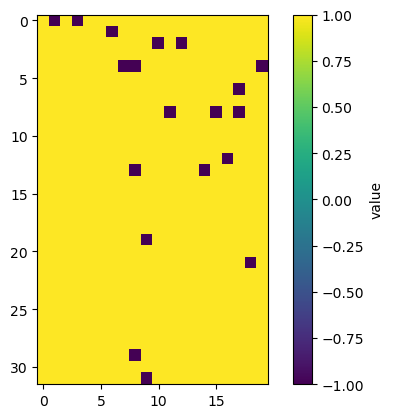

In [226]:
cond=np.load("../data/svm/cond_sub_base_20250427_newpos.npy")
cond = cond -cond_reference

m = cond/cond_range*weight_max

m=np.ones_like(m)
coordinates=np.load("../data/svm/coordinates.npy",)
for i in range(len(coordinates[0])):
    m[coordinates[1][i],coordinates[0][i]]=-1

from util import plot_v_cond,plot_cond,show_crossbar,DataLoader
plot_cond(m[:128,:].reshape(32,20),vmin=-1,vmax=1,label="value")

In [227]:
# -------------------------------
# 2. 多分类 SVM（Crammer–Singer形式）问题推导与训练
# -------------------------------
# 对于每个输入 x_i，各类别得分为:
#       s_k = w_k^T x_i + b_k,
# 其中 W 为大小 (K, d) 的权重矩阵，b 为大小 (K,) 的偏置向量。
#
# 损失函数定义为：
#       L = (1/N) * sum_{i=1}^N [sum_{j≠y_i} max(0, 1 - (s_{y_i} - s_j))] + (λ/2) * ||W||^2
#
# 对于每个样本 i，其 margin 定义为：
#       margin_j = s_j - s_{y_i} + 1,  (j ≠ y_i)
# 对于正确类别则不计算 loss（可记为 0）。
#
# 子梯度计算：
# 对于 j ≠ y_i, 当 margin_j > 0，有：
#       ∂L/∂w_j += x_i,   ∂L/∂b_j += 1;
# 对于 j = y_i，有：
#       ∂L/∂w_{y_i} -= (number of positive margins for sample i) * x_i,
#       ∂L/∂b_{y_i} -= (number of positive margins for sample i).
#
# 加上正则化项 (λ/2)*||W||^2 后，
#       ∂L/∂W = computed_gradient + λ*W.
#
# 我们采用 mini-batch 子梯度下降来训练模型。

In [235]:
loss_history = []
num_iters=10000
for it in range(num_iters):
    # 随机采样 mini-batch
    batch_idx = np.random.choice(num_samples, batch_size, replace=False)
    X_batch = X[batch_idx]
    y_batch = y[batch_idx]

    # 计算得分矩阵，尺寸 (batch_size, K)
    scores = np.dot(X_batch, W.T) + b

    # 取出每个样本的正确类别得分，尺寸 (batch_size, 1)
    correct_scores = scores[np.arange(batch_size), y_batch].reshape(-1, 1)

    # 计算 margin = s_j - s_{y_i} + 1
    margins = scores - correct_scores + 1
    margins[np.arange(batch_size), y_batch] = 0  # 正确类别不计算 loss

    # 只保留正 margin
    margins = np.maximum(0, margins)

    # 计算损失：平均损失 + 正则化项
    loss = np.sum(margins) / batch_size + 0.5 * lambda_reg * np.sum(W * W)
    loss_history.append(loss)

    # -------------------------------
    # 计算梯度（子梯度）
    # -------------------------------
    # 构造指示矩阵，若 margin > 0 则记为 1
    indicator = (margins > 0).astype(float)
    # 每个样本计算正 margin 的数量
    row_sum = np.sum(indicator, axis=1)  # (batch_size,)
    # 对正确类别的梯度修正
    indicator[np.arange(batch_size), y_batch] = -row_sum

    # 计算梯度：W 的梯度 (K, d)，b 的梯度 (K,)
    dW = np.dot(indicator.T, X_batch) / batch_size + lambda_reg * W
    db = np.sum(indicator, axis=0) / batch_size

    # 参数更新
    W -= learning_rate * dW
    np.clip(W,-1,1,out=W)
    W[coordinates]=W2[coordinates]
    b -= learning_rate * db
    np.clip(b,-1,1,out=b)

    if it % 100 == 0:
        scores_all = np.dot(X, W.T) + b  # 整个训练集的得分，尺寸 (num_samples, K)
        y_pred = np.argmax(scores_all, axis=1)  # 预测的类别（0~K-1）
        acc = np.mean(y_pred == y)

        # 输出当前迭代的损失和预测准确率
        print(f"Iter {it + 1}/{num_iters}: Loss = {loss:.4f}, Accuracy = {acc * 100:.2f}%")
        # print(f"Iteration {it}/{num_iters}, loss = {loss:.4f}")


Iter 1/10000: Loss = 0.6533, Accuracy = 83.63%
Iter 101/10000: Loss = 0.6156, Accuracy = 83.63%
Iter 201/10000: Loss = 0.5579, Accuracy = 83.63%
Iter 301/10000: Loss = 0.6295, Accuracy = 83.63%
Iter 401/10000: Loss = 0.4997, Accuracy = 83.64%
Iter 501/10000: Loss = 0.5580, Accuracy = 83.64%
Iter 601/10000: Loss = 0.6598, Accuracy = 83.69%
Iter 701/10000: Loss = 0.6641, Accuracy = 83.65%
Iter 801/10000: Loss = 0.5462, Accuracy = 83.65%
Iter 901/10000: Loss = 0.4690, Accuracy = 83.70%
Iter 1001/10000: Loss = 0.5203, Accuracy = 83.65%
Iter 1101/10000: Loss = 0.6328, Accuracy = 83.65%
Iter 1201/10000: Loss = 0.5683, Accuracy = 83.67%
Iter 1301/10000: Loss = 0.5370, Accuracy = 83.71%
Iter 1401/10000: Loss = 0.6728, Accuracy = 83.71%
Iter 1501/10000: Loss = 0.7697, Accuracy = 83.71%
Iter 1601/10000: Loss = 0.6502, Accuracy = 83.71%
Iter 1701/10000: Loss = 0.6755, Accuracy = 83.71%
Iter 1801/10000: Loss = 0.7504, Accuracy = 83.71%
Iter 1901/10000: Loss = 0.6246, Accuracy = 83.72%
Iter 2001/10

In [236]:
# -------------------------------
# 3. 保存 SVM 参数矩阵
# -------------------------------
# 合并 W 和 b 得到一个 K×(d+1) 的矩阵：
# 前 d 列为权重，最后一列为偏置
Wb = np.hstack((W, b.reshape(K, 1)))
print("最终模型参数矩阵的尺寸 (K x [d+1]) =", Wb.shape)

# 保存参数矩阵到 .mat 文件
sio.savemat('../data/svm/multi_svm_params8395.mat', {'Wb': Wb})
print("训练得到的 SVM 参数矩阵已保存到 'multi_svm_params.mat' 文件中。")

# -------------------------------
# 4. 读入参数矩阵并进行预测
# -------------------------------
# 假设我们需要对新数据 X_new (形状: (N_new, d)) 进行预测
# 此处举个例子，

最终模型参数矩阵的尺寸 (K x [d+1]) = (5, 129)
训练得到的 SVM 参数矩阵已保存到 'multi_svm_params.mat' 文件中。


In [73]:
loss_history = []
num_iters=200000
for it in range(num_iters):
    # 随机采样 mini-batch
    batch_idx = np.random.choice(num_samples, batch_size, replace=False)
    X_batch = X[batch_idx]
    y_batch = y[batch_idx]

    # 计算得分矩阵，尺寸 (batch_size, K)
    scores = np.dot(X_batch, W.T) + b

    # 取出每个样本的正确类别得分，尺寸 (batch_size, 1)
    correct_scores = scores[np.arange(batch_size), y_batch].reshape(-1, 1)

    # 计算 margin = s_j - s_{y_i} + 1
    margins = scores - correct_scores + 1
    margins[np.arange(batch_size), y_batch] = 0  # 正确类别不计算 loss

    # 只保留正 margin
    margins = np.maximum(0, margins)

    # 计算损失：平均损失 + 正则化项
    loss = np.sum(margins) / batch_size + 0.5 * lambda_reg * np.sum(W * W)
    loss_history.append(loss)

    # -------------------------------
    # 计算梯度（子梯度）
    # -------------------------------
    # 构造指示矩阵，若 margin > 0 则记为 1
    indicator = (margins > 0).astype(float)
    # 每个样本计算正 margin 的数量
    row_sum = np.sum(indicator, axis=1)  # (batch_size,)
    # 对正确类别的梯度修正
    indicator[np.arange(batch_size), y_batch] = -row_sum

    # 计算梯度：W 的梯度 (K, d)，b 的梯度 (K,)
    dW = np.dot(indicator.T, X_batch) / batch_size + lambda_reg * W
    db = np.sum(indicator, axis=0) / batch_size

    # 参数更新
    W -= learning_rate * dW
    np.clip(W,-1,1,out=W)
    W[coordinates]=W2[coordinates]
    b -= learning_rate * db

    if it % 100 == 0:
        scores_all = np.dot(X, W.T) + b  # 整个训练集的得分，尺寸 (num_samples, K)
        y_pred = np.argmax(scores_all, axis=1)  # 预测的类别（0~K-1）
        acc = np.mean(y_pred == y)

        # 输出当前迭代的损失和预测准确率
        print(f"Iter {it + 1}/{num_iters}: Loss = {loss:.4f}, Accuracy = {acc * 100:.2f}%")
        # print(f"Iteration {it}/{num_iters}, loss = {loss:.4f}")


Iter 1/200000: Loss = 0.6101, Accuracy = 85.91%
Iter 101/200000: Loss = 0.5301, Accuracy = 85.91%
Iter 201/200000: Loss = 0.5451, Accuracy = 85.91%
Iter 301/200000: Loss = 0.4140, Accuracy = 85.91%
Iter 401/200000: Loss = 0.3656, Accuracy = 85.91%
Iter 501/200000: Loss = 0.4257, Accuracy = 85.91%
Iter 601/200000: Loss = 0.5286, Accuracy = 85.91%
Iter 701/200000: Loss = 0.4927, Accuracy = 85.91%
Iter 801/200000: Loss = 0.4925, Accuracy = 85.91%
Iter 901/200000: Loss = 0.4705, Accuracy = 85.91%
Iter 1001/200000: Loss = 0.6072, Accuracy = 85.91%
Iter 1101/200000: Loss = 0.3875, Accuracy = 85.91%
Iter 1201/200000: Loss = 0.4786, Accuracy = 85.91%
Iter 1301/200000: Loss = 0.4985, Accuracy = 85.91%
Iter 1401/200000: Loss = 0.3705, Accuracy = 85.91%
Iter 1501/200000: Loss = 0.4488, Accuracy = 85.91%
Iter 1601/200000: Loss = 0.5738, Accuracy = 85.91%
Iter 1701/200000: Loss = 0.4645, Accuracy = 85.91%
Iter 1801/200000: Loss = 0.5158, Accuracy = 85.91%
Iter 1901/200000: Loss = 0.5304, Accuracy =

In [88]:
# -------------------------------
# 3. 保存 SVM 参数矩阵
# -------------------------------
# 合并 W 和 b 得到一个 K×(d+1) 的矩阵：
# 前 d 列为权重，最后一列为偏置
Wb = np.hstack((W, b.reshape(K, 1)))
print("最终模型参数矩阵的尺寸 (K x [d+1]) =", Wb.shape)

# 保存参数矩阵到 .mat 文件
sio.savemat('multi_svm_params.mat', {'Wb': Wb})
print("训练得到的 SVM 参数矩阵已保存到 'multi_svm_params.mat' 文件中。")

# -------------------------------
# 4. 读入参数矩阵并进行预测
# -------------------------------
# 假设我们需要对新数据 X_new (形状: (N_new, d)) 进行预测
# 此处举个例子，

最终模型参数矩阵的尺寸 (K x [d+1]) = (5, 129)
训练得到的 SVM 参数矩阵已保存到 'multi_svm_params.mat' 文件中。
